In [ ]:
import pandas as pd
# sales = pd.read_csv('D:\depi project\m5-forecasting\\train_before_2016.csv')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Mega Store\AppData\Local\Temp\ipykernel_6240\2982172967.py:2: SyntaxWarning: invalid escape sequence '\d'
  sales = pd.read_csv('D:\depi project\m5-forecasting\\train_before_2016.csv')
C:\Users\Mega Store\AppData\Local\Temp\ipykernel_6240\2982172967.py:2: DtypeWarning: Columns (14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv('D:\depi project\m5-forecasting\\train_before_2016.csv')


In [40]:
sales[sales['d_1000']!=0].sort_values('d_1000', ascending=False)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
8412,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,108,132,102,120,...,129,160,204,86,100,88,77,141,139,130
20608,FOODS_3_090_TX_3_validation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,203,112,128,76,...,84,75,83,81,46,53,43,70,102,66
17559,FOODS_3_090_TX_2_validation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,164,215,94,127,...,68,124,86,43,61,46,35,54,83,73
18055,FOODS_3_586_TX_2_validation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,98,85,47,56,...,80,78,102,54,67,57,59,80,100,75
2314,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,107,182,47,47,...,47,82,83,30,45,29,53,87,95,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,HOBBIES_1_021_CA_1_validation,HOBBIES_1_021,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,2,3,0,0,0,0,0,1,0
19,HOBBIES_1_020_CA_1_validation,HOBBIES_1_020,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
14,HOBBIES_1_015_CA_1_validation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,4,0,0,5,...,1,4,2,2,1,0,0,2,5,4
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,1,0,1,0,0,1,1


In [34]:
grouped=prices.groupby(['store_id', 'item_id'])['sell_price'].sum()

In [30]:
prices[(prices['store_id']=='TX_3')].sort_values('sell_price', ascending=False)

,store_id,item_id,wm_yr_wk,sell_price
4159131,TX_3,HOBBIES_1_225,11330,30.98
4159126,TX_3,HOBBIES_1_225,11325,30.98
4159133,TX_3,HOBBIES_1_225,11332,30.98
4159132,TX_3,HOBBIES_1_225,11331,30.98
4123380,TX_3,HOBBIES_1_060,11423,30.98
...,...,...,...,...
4798167,TX_3,FOODS_3_816,11339,0.05
4210559,TX_3,HOBBIES_2_021,11611,0.05
4709139,TX_3,FOODS_3_412,11432,0.05
4728843,TX_3,FOODS_3_498,11324,0.02


In [33]:
grouped[(grouped.index.get_level_values('store_id')=='TX_3')].sort_values( ascending=True)

store_id  item_id        
TX_3      HOBBIES_2_026        14.03
          HOBBIES_1_019        31.44
          FOODS_3_070          33.83
          HOBBIES_1_232        36.66
          FOODS_3_412          44.79
                              ...   
          HOUSEHOLD_2_211    5617.92
          HOBBIES_1_060      5935.67
          HOBBIES_1_361      6025.58
          HOBBIES_1_225      6055.55
          HOUSEHOLD_2_446    7344.33
Name: sell_price, Length: 3049, dtype: float64

In [ ]:
# TX_3      HOUSEHOLD_2_446 highest price
# TX_3      HOBBIES_2_026 lowest price

In [42]:
sample = sales[
    (sales['item_id'] == 'HOUSEHOLD_2_446') &
    (sales['store_id'] == 'TX_3')
]

ts = sample.iloc[:, 6:].T   # من d_1 إلى d_x
ts.columns = ['sales']
ts = ts.reset_index()
ts.columns = ['day', 'sales']

# تحويل day إلى رقم
ts['day'] = ts['day'].str.replace('d_', '').astype(int)

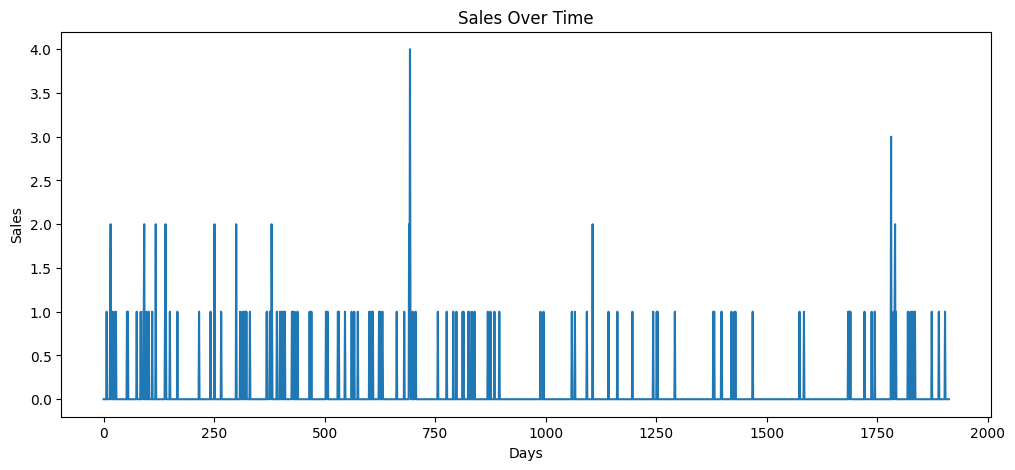

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts['sales'])
plt.title("Sales Over Time")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

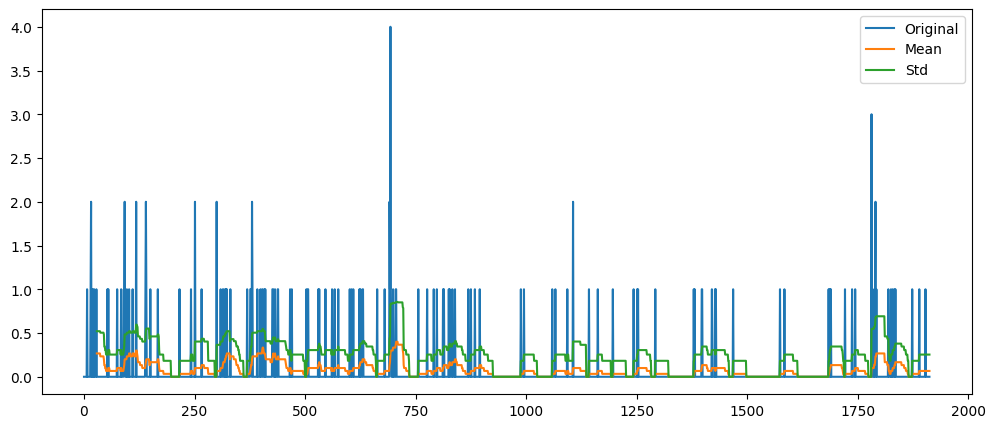

In [44]:
rolling_mean = ts['sales'].rolling(30).mean()
rolling_std = ts['sales'].rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(ts['sales'], label='Original')
plt.plot(rolling_mean, label='Mean')
plt.plot(rolling_std, label='Std')
plt.legend()
plt.show()

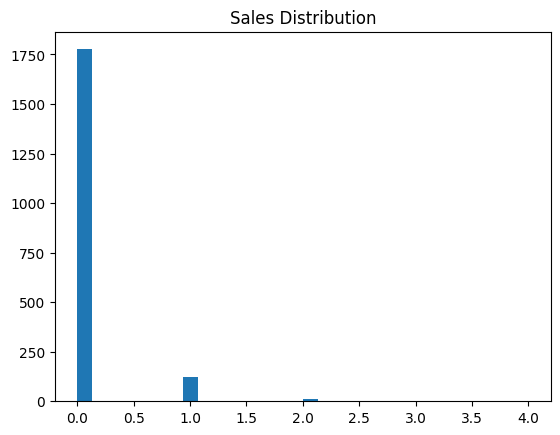

In [45]:
plt.hist(ts['sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

In [ ]:
ts = sample.filter(like='d_').T
ts.columns = ['sales']
ts = ts.reset_index()
ts.columns = ['day', 'sales']
ts = ts.merge(calender, left_on='day', right_on='d')

<Axes: xlabel='wday'>

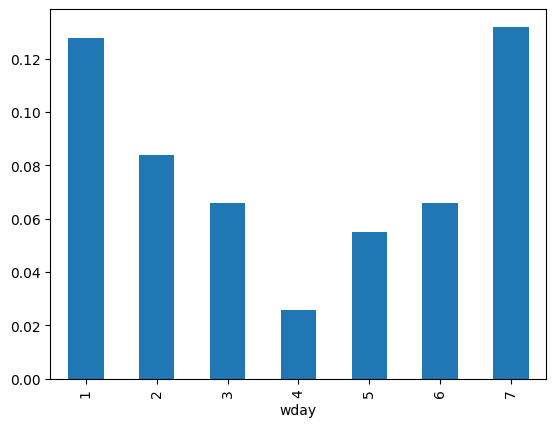

In [50]:
ts.groupby('wday')['sales'].mean().plot(kind='bar')

<Axes: xlabel='month'>

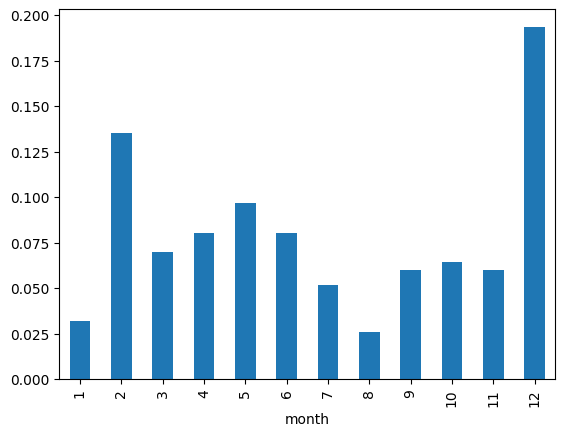

In [53]:
ts.groupby('month')['sales'].mean().plot(kind='bar')

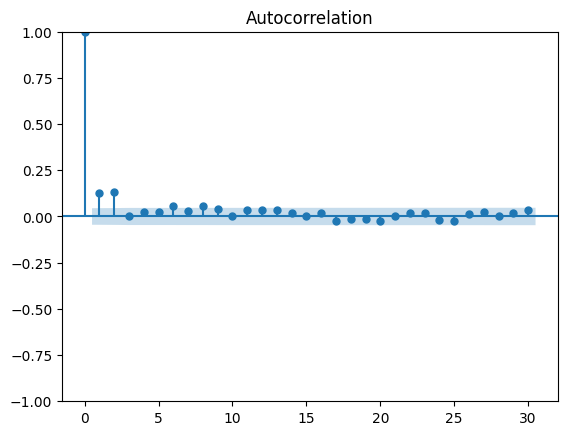

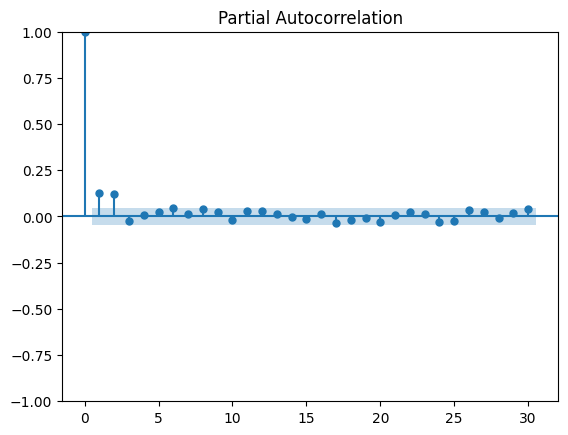

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts['sales'], lags=30)
plt.show()

plot_pacf(ts['sales'], lags=30)
plt.show()

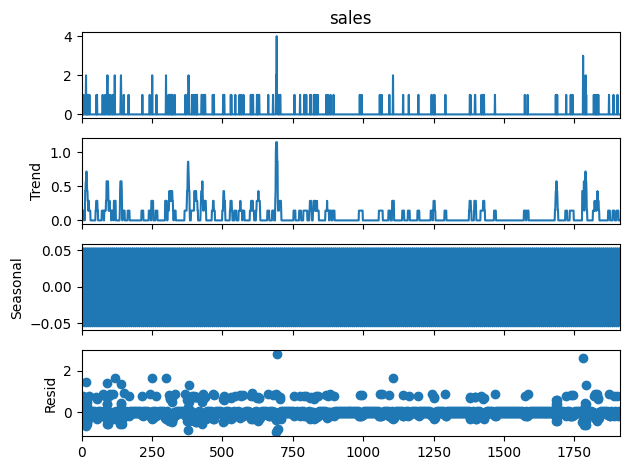

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts['sales'], period=7)

result.plot()
plt.show()

In [58]:
(ts['sales'] == 0).mean()

np.float64(0.9283847360167277)